In [1]:
# ============================================
# STEP 3: DATA PREPROCESSING, EDA & FEATURE ENGINEERING
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the original raw dataset
df = pd.read_csv("data.csv", sep=";")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows: 4,424
Columns: 37


In [3]:
# Remove leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

print("Column names standardized.")
print(df.columns.tolist())

Column names standardized.
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GD

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Dataset shape:", df.shape)

Missing values: 0
Duplicate rows: 0
Dataset shape: (4424, 37)


In [5]:
# Convert the original 3-class target into binary classification

df["Dropout_Binary"] = (df["Target"] == "Dropout").astype(int)

print(df["Dropout_Binary"].value_counts())

Dropout_Binary
0    3003
1    1421
Name: count, dtype: int64


In [6]:
binary_target_distribution = (
    df["Dropout_Binary"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(binary_target_distribution.round(2))

Dropout_Binary
0    67.88
1    32.12
Name: proportion, dtype: float64


In [7]:
target_check = pd.crosstab(
    df["Target"],
    df["Dropout_Binary"]
)

target_check

Dropout_Binary,0,1
Target,,
Dropout,0,1421
Enrolled,794,0
Graduate,2209,0


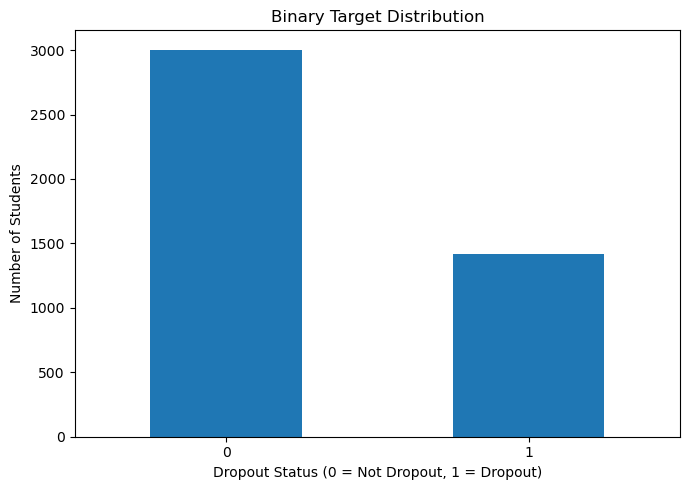

In [8]:
plt.figure(figsize=(7, 5))

df["Dropout_Binary"].value_counts().sort_index().plot(kind="bar")

plt.title("Binary Target Distribution")
plt.xlabel("Dropout Status (0 = Not Dropout, 1 = Dropout)")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
# Variables representing academic performance after enrolment
post_enrollment_features = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

print("Post-enrollment variables excluded from the primary early-risk model:")

for feature in post_enrollment_features:
    print("-", feature)

Post-enrollment variables excluded from the primary early-risk model:
- Curricular units 1st sem (credited)
- Curricular units 1st sem (enrolled)
- Curricular units 1st sem (evaluations)
- Curricular units 1st sem (approved)
- Curricular units 1st sem (grade)
- Curricular units 1st sem (without evaluations)
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (grade)
- Curricular units 2nd sem (without evaluations)


### Leakage and Prediction-Timing Decision

The dataset contains curricular-unit variables describing first- and second-semester academic activity and performance. These variables occur after the initial enrollment decision and therefore may not be available when an institution first identifies students requiring support.

Because the project's business objective is early identification of students at risk of dropout, these post-enrollment academic variables are excluded from the primary prediction feature set. This reduces the risk of temporal data leakage and ensures that the primary model reflects information that could realistically support earlier intervention.

The excluded variables remain available for exploratory analysis and will be discussed as a potential source of leakage and as a limitation of the dataset.

In [10]:
# Remove original target and leakage-prone post-enrollment variables

model_df = df.drop(
    columns=["Target"] + post_enrollment_features
).copy()

print("Modelling dataset shape:", model_df.shape)
print(model_df.head())

Modelling dataset shape: (4424, 25)
   Marital status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0            1                       1   
2 

In [11]:
# ============================================================
# DOMAIN-BASED FEATURE ENGINEERING
# ============================================================

# 1. Age-group binning
model_df["Age_Group"] = pd.cut(
    model_df["Age at enrollment"],
    bins=[0, 19, 24, 29, np.inf],
    labels=["Under 20", "20-24", "25-29", "30+"],
    right=True
)

# 2. Whether parents have the same qualification category
model_df["Parental_Qualification_Same"] = (
    model_df["Mother's qualification"] ==
    model_df["Father's qualification"]
).astype(int)

# 3. Whether parents have the same occupation category
model_df["Parental_Occupation_Same"] = (
    model_df["Mother's occupation"] ==
    model_df["Father's occupation"]
).astype(int)

# 4. Early financial-risk indicator
model_df["Financial_Risk_Flag"] = (
    (model_df["Debtor"] == 1) |
    (model_df["Tuition fees up to date"] == 0)
).astype(int)

print("Engineered features created successfully.")

print("\nAge group distribution:")
print(model_df["Age_Group"].value_counts().sort_index())

print("\nFinancial risk distribution:")
print(model_df["Financial_Risk_Flag"].value_counts())

Engineered features created successfully.

Age group distribution:
Age_Group
Under 20    1952
20-24       1334
25-29        427
30+          711
Name: count, dtype: int64

Financial risk distribution:
Financial_Risk_Flag
0    3639
1     785
Name: count, dtype: int64


In [12]:
X = model_df.drop(columns=["Dropout_Binary"])
y = model_df["Dropout_Binary"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4424, 28)
y shape: (4424,)


In [13]:
# ============================================================
# FINAL FEATURE LISTS
# ============================================================

categorical_features = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International",
    "Age_Group"
]

numerical_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
    "Parental_Qualification_Same",
    "Parental_Occupation_Same",
    "Financial_Risk_Flag"
]

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total modelling features:", len(categorical_features) + len(numerical_features))

Categorical features: 19
Numerical features: 9
Total modelling features: 28


In [14]:
all_features = categorical_features + numerical_features

missing_from_lists = [
    column for column in X.columns
    if column not in all_features
]

extra_in_lists = [
    column for column in all_features
    if column not in X.columns
]

print("Features missing from classification lists:", missing_from_lists)
print("Features incorrectly included:", extra_in_lists)

Features missing from classification lists: []
Features incorrectly included: []


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (3539, 28)
Testing set: (885, 28)

Training target distribution:
Dropout_Binary
0    0.679
1    0.321
Name: proportion, dtype: float64

Testing target distribution:
Dropout_Binary
0    0.679
1    0.321
Name: proportion, dtype: float64


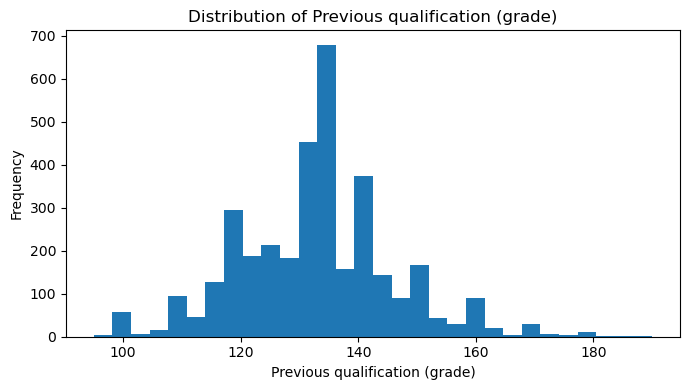

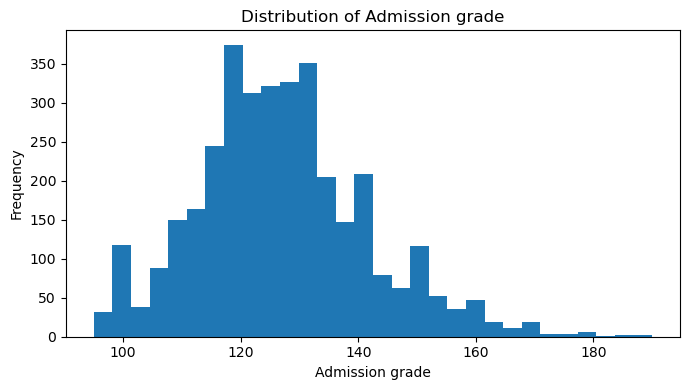

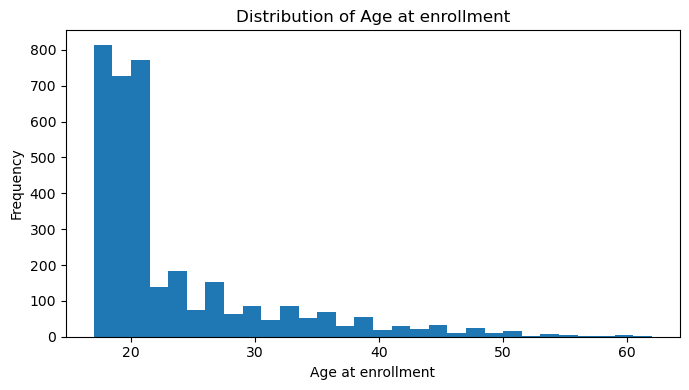

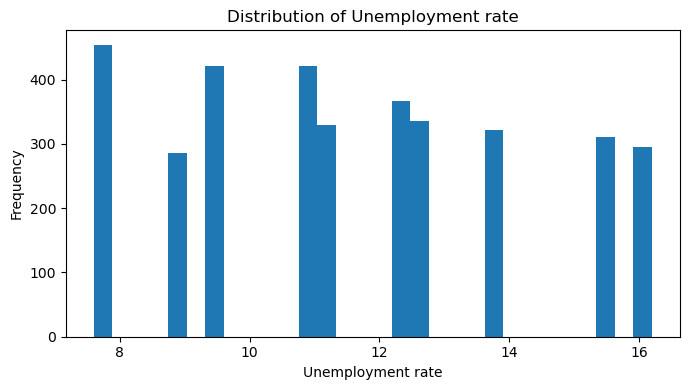

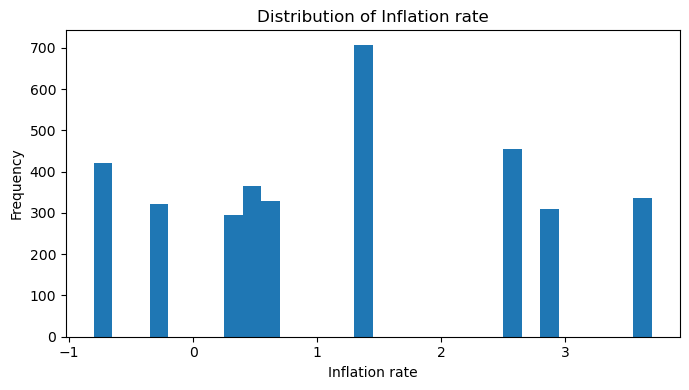

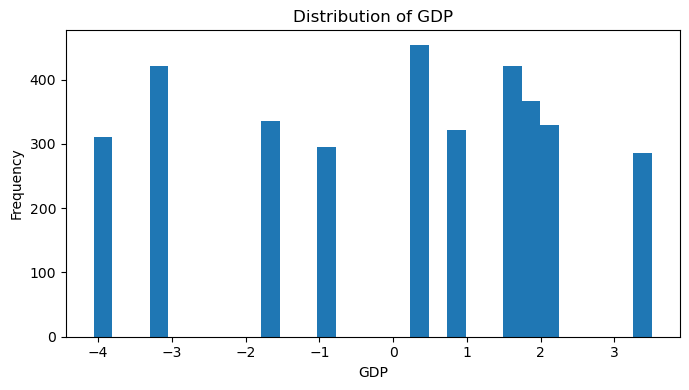

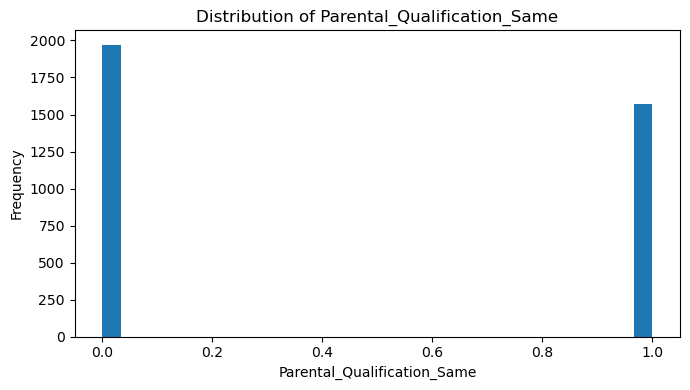

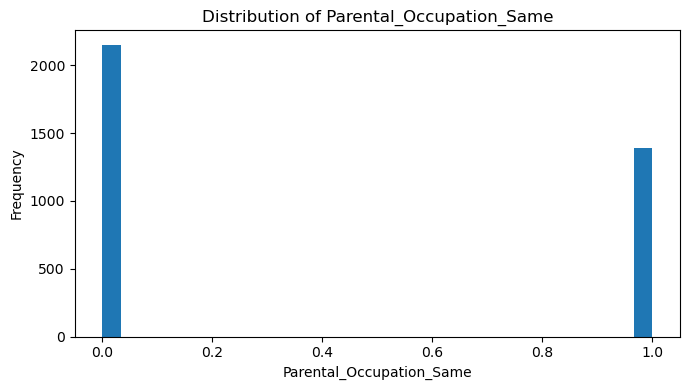

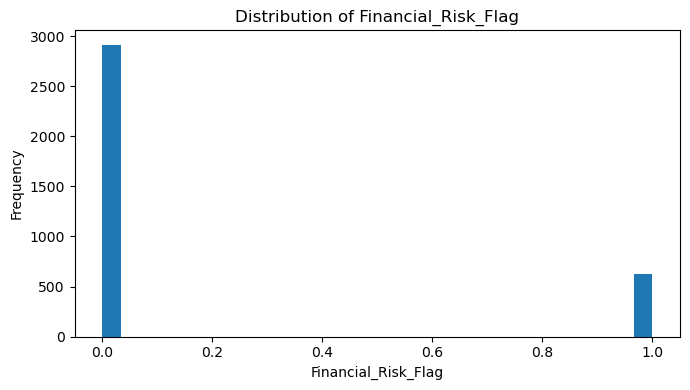

In [16]:
for column in numerical_features:

    plt.figure(figsize=(7, 4))

    plt.hist(X_train[column], bins=30)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

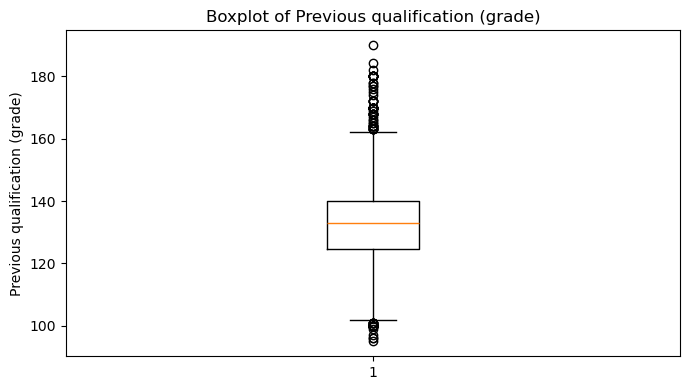

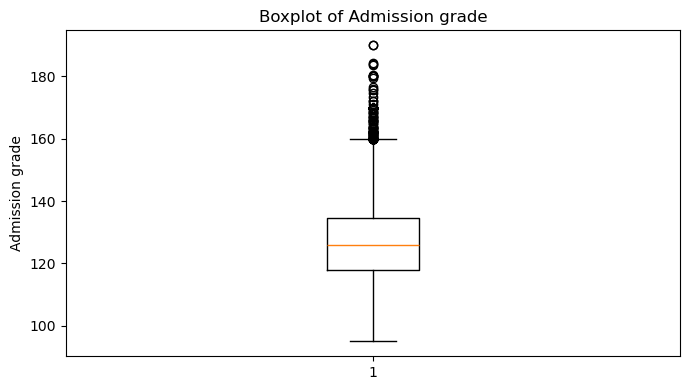

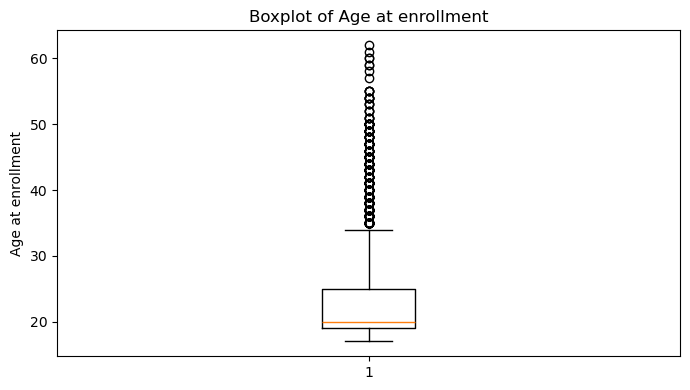

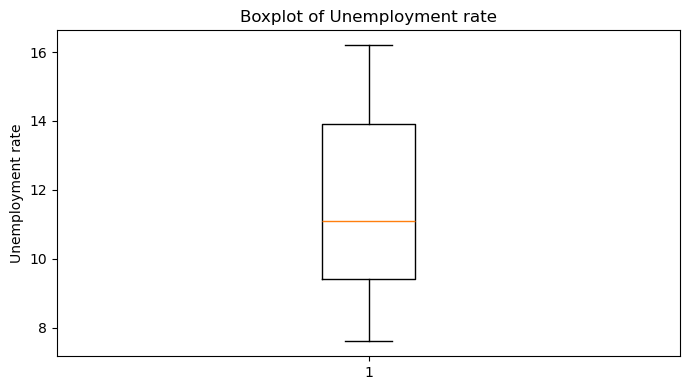

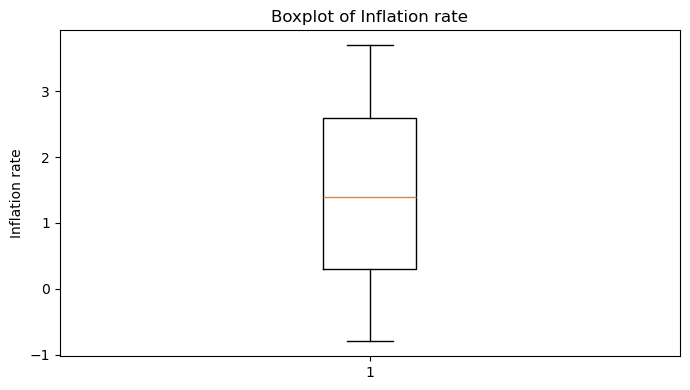

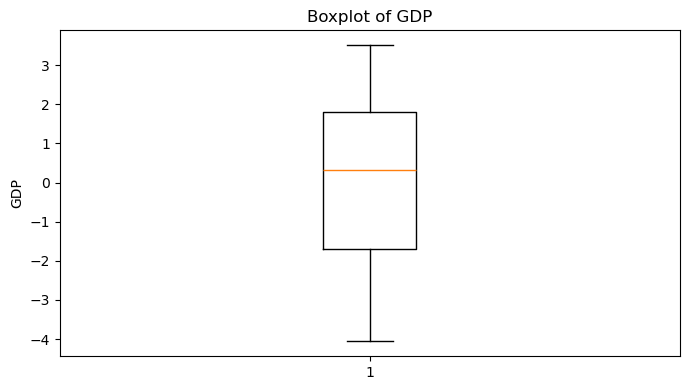

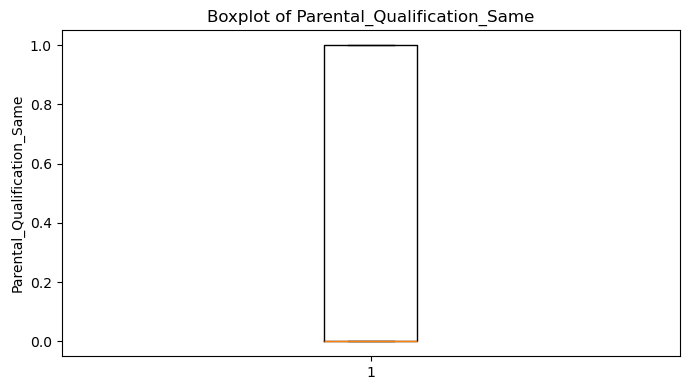

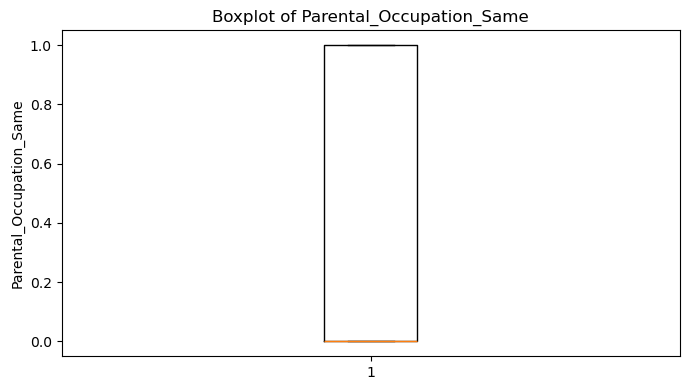

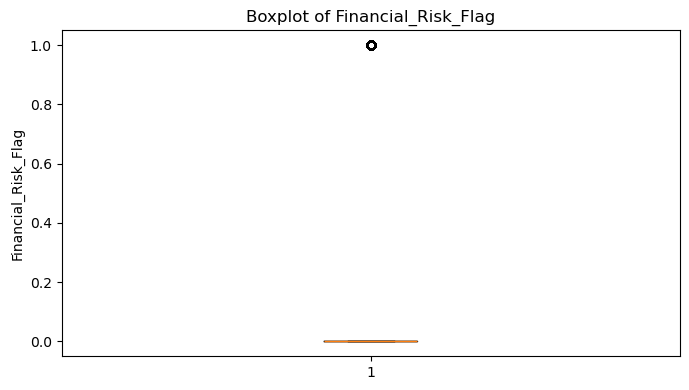

In [17]:
for column in numerical_features:

    plt.figure(figsize=(7, 4))

    plt.boxplot(X_train[column].dropna())

    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [18]:
for column in numerical_features:

    grouped = X_train.copy()
    grouped["Dropout"] = y_train.values

    dropout_means = grouped.groupby("Dropout")[column].mean()

    print(f"\n{column}")
    print(dropout_means)


Previous qualification (grade)
Dropout
0    133.230308
1    131.530255
Name: Previous qualification (grade), dtype: float64

Admission grade
Dropout
0    127.869650
1    125.119877
Name: Admission grade, dtype: float64

Age at enrollment
Dropout
0    21.943381
1    25.832894
Name: Age at enrollment, dtype: float64

Unemployment rate
Dropout
0    11.572523
1    11.614952
Name: Unemployment rate, dtype: float64

Inflation rate
Dropout
0    1.191757
1    1.279332
Name: Inflation rate, dtype: float64

GDP
Dropout
0    0.078376
1   -0.130158
Name: GDP, dtype: float64

Parental_Qualification_Same
Dropout
0    0.421732
1    0.489006
Name: Parental_Qualification_Same, dtype: float64

Parental_Occupation_Same
Dropout
0    0.376769
1    0.425682
Name: Parental_Occupation_Same, dtype: float64

Financial_Risk_Flag
Dropout
0    0.077435
1    0.387863
Name: Financial_Risk_Flag, dtype: float64


<Figure size 700x500 with 0 Axes>

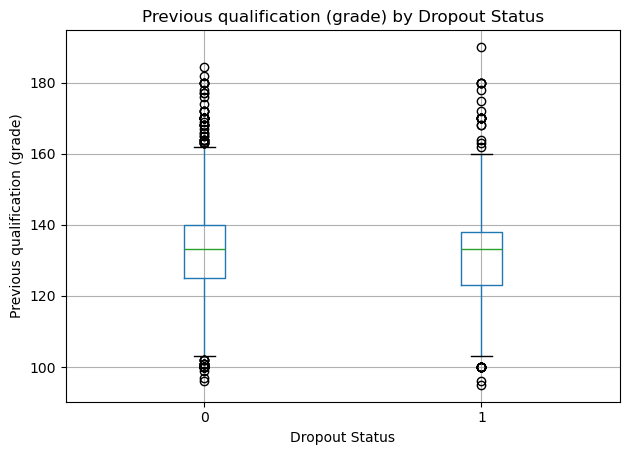

<Figure size 700x500 with 0 Axes>

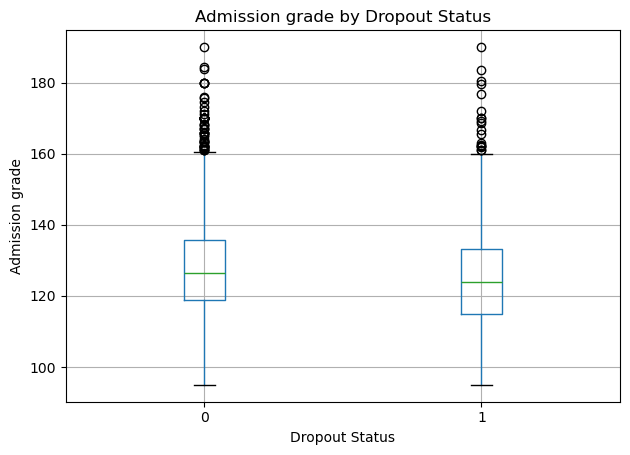

<Figure size 700x500 with 0 Axes>

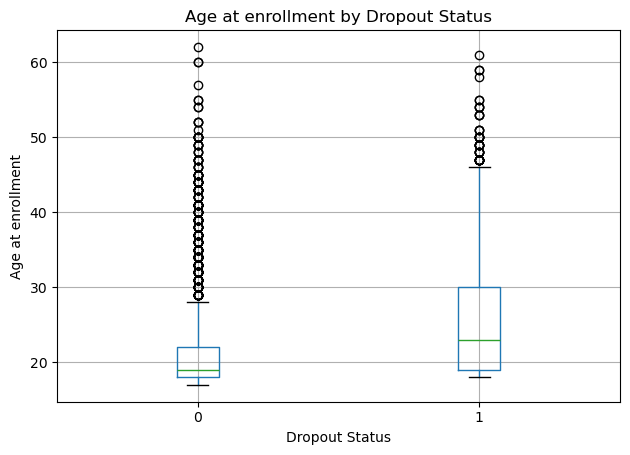

<Figure size 700x500 with 0 Axes>

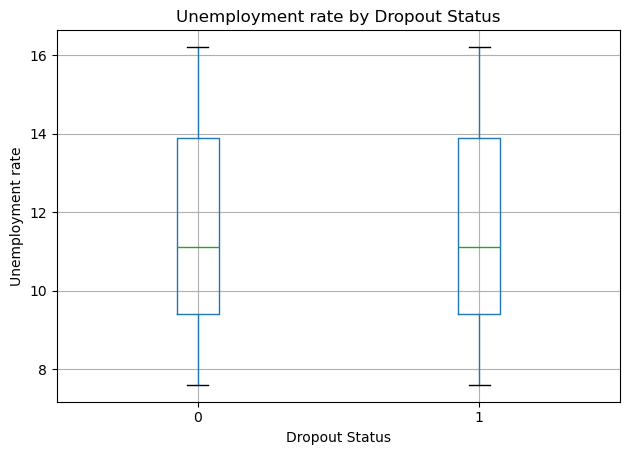

<Figure size 700x500 with 0 Axes>

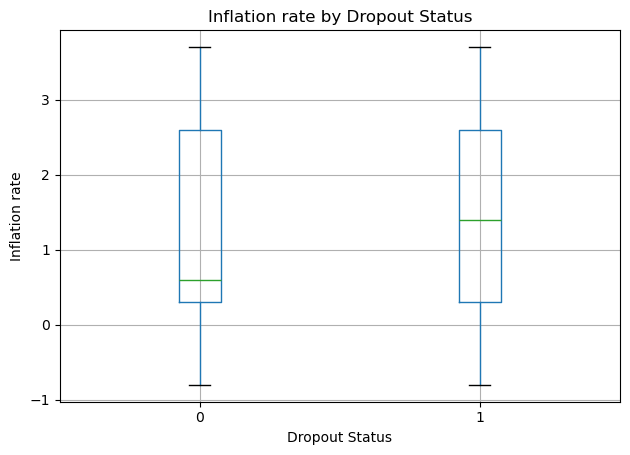

<Figure size 700x500 with 0 Axes>

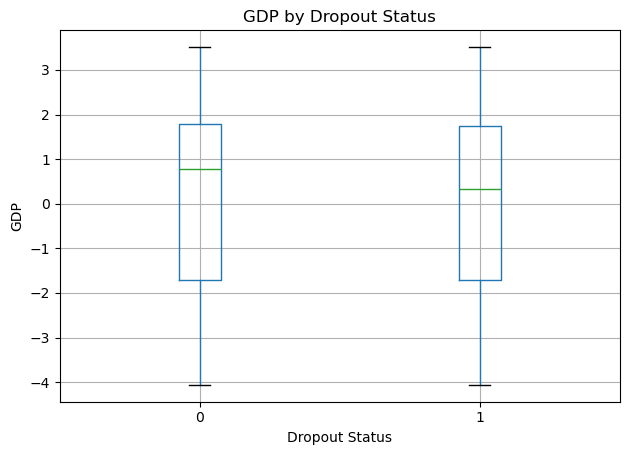

<Figure size 700x500 with 0 Axes>

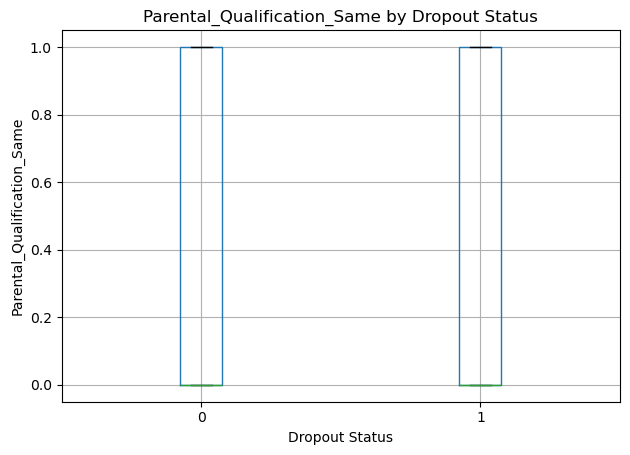

<Figure size 700x500 with 0 Axes>

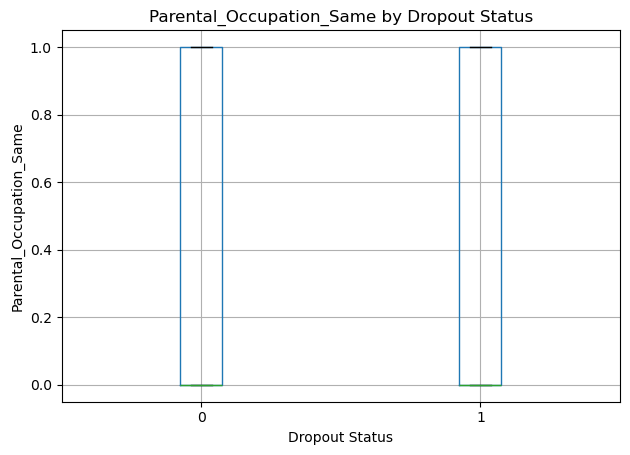

<Figure size 700x500 with 0 Axes>

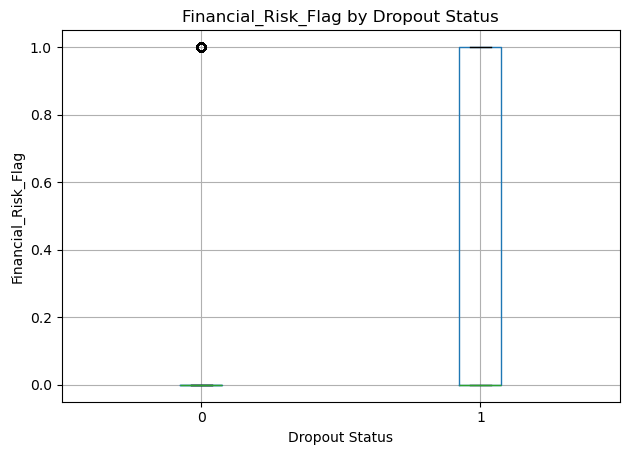

In [19]:
for column in numerical_features:

    grouped = X_train.copy()
    grouped["Dropout"] = y_train.values

    plt.figure(figsize=(7, 5))

    grouped.boxplot(
        column=column,
        by="Dropout"
    )

    plt.title(f"{column} by Dropout Status")
    plt.suptitle("")
    plt.xlabel("Dropout Status")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [20]:
for column in categorical_features:

    crosstab = pd.crosstab(
        X_train[column],
        y_train,
        normalize="index"
    )

    if 1 in crosstab.columns:

        print(f"\n--- {column} ---")
        print(
            (crosstab[1] * 100)
            .round(2)
            .sort_values(ascending=False)
            .head(15)
        )


--- Marital status ---
Marital status
6    75.00
2    45.95
4    43.48
5    40.91
1    30.47
3    25.00
Name: 1, dtype: float64

--- Application mode ---
Application mode
26    100.00
2     100.00
27    100.00
7      58.56
39     55.32
42     40.62
18     37.25
43     36.51
51     33.33
10     33.33
17     30.10
44     29.31
15     20.83
1      20.30
53     15.38
Name: 1, dtype: float64

--- Application order ---
Application order
5    36.00
1    34.60
2    27.93
3    24.48
4    23.98
6    21.70
0     0.00
9     0.00
Name: 1, dtype: float64

--- Course ---
Course
33      66.67
9130    56.14
9119    53.28
9991    50.23
9556    42.65
9853    42.58
9254    40.40
9003    39.88
9147    37.09
9670    36.59
171     34.52
8014    32.54
9773    29.39
9085    27.92
9070    23.44
Name: 1, dtype: float64

--- Daytime/evening attendance ---
Daytime/evening attendance
0    42.49
1    30.86
Name: 1, dtype: float64

--- Previous qualification ---
Previous qualification
5     100.00
9     100.00
10   

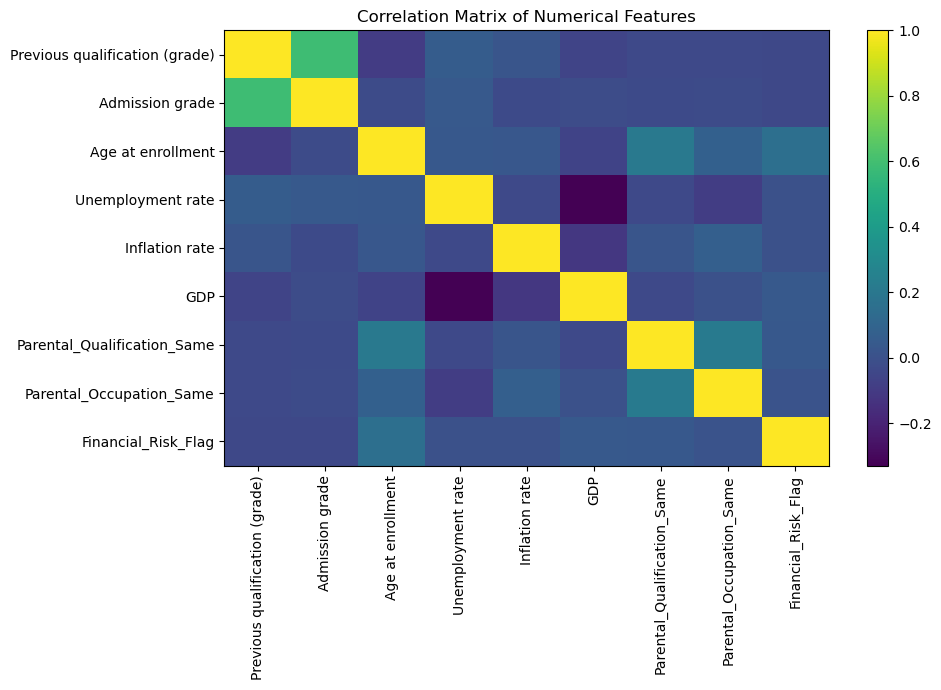

In [21]:
correlation_matrix = X_train[numerical_features].corr()

plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(numerical_features)),
    numerical_features,
    rotation=90
)

plt.yticks(
    range(len(numerical_features)),
    numerical_features
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

In [22]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [23]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (3539, 245)
Processed testing shape: (885, 245)


In [24]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 30 processed features:")

for feature in feature_names[:30]:
    print(feature)

Number of processed features: 245

First 30 processed features:
num__Previous qualification (grade)
num__Admission grade
num__Age at enrollment
num__Unemployment rate
num__Inflation rate
num__GDP
num__Parental_Qualification_Same
num__Parental_Occupation_Same
num__Financial_Risk_Flag
cat__Marital status_1
cat__Marital status_2
cat__Marital status_3
cat__Marital status_4
cat__Marital status_5
cat__Marital status_6
cat__Application mode_1
cat__Application mode_2
cat__Application mode_5
cat__Application mode_7
cat__Application mode_10
cat__Application mode_15
cat__Application mode_16
cat__Application mode_17
cat__Application mode_18
cat__Application mode_26
cat__Application mode_27
cat__Application mode_39
cat__Application mode_42
cat__Application mode_43
cat__Application mode_44


In [25]:
mi_scores = mutual_info_classif(
    X_train_processed,
    y_train,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": feature_names,
    "Mutual Information": mi_scores
})

mi_results = mi_results.sort_values(
    by="Mutual Information",
    ascending=False
).reset_index(drop=True)

mi_results.head(20)

,Feature,Mutual Information
0,cat__Tuition fees up to date_1,0.095655
1,cat__Tuition fees up to date_0,0.083535
2,num__Financial_Risk_Flag,0.074621
3,num__Age at enrollment,0.034543
4,num__Previous qualification (grade),0.034523
5,cat__Scholarship holder_1,0.032387
6,cat__Gender_1,0.029576
7,cat__Age_Group_Under 20,0.026694
8,cat__Debtor_1,0.025980
9,cat__Debtor_0,0.025855


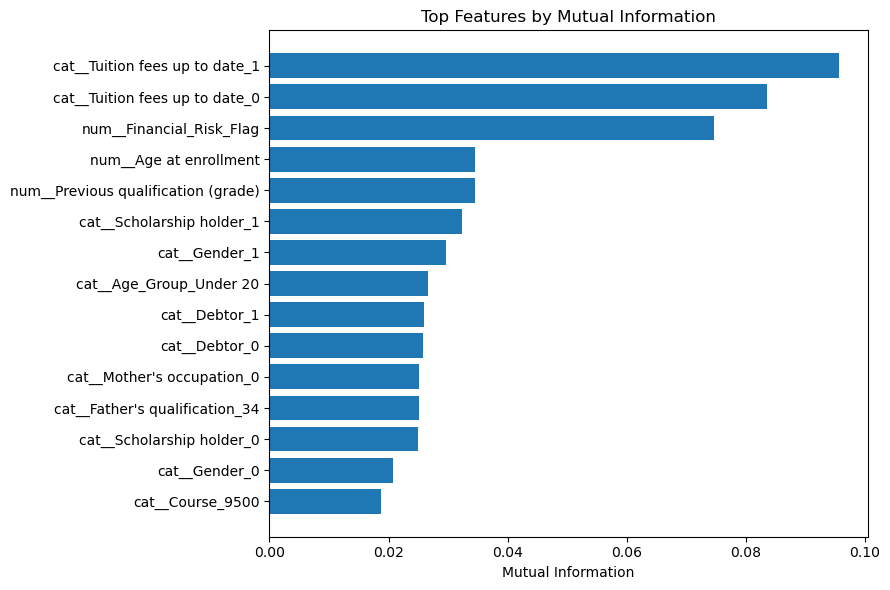

In [26]:
top_features = mi_results.head(15).sort_values(
    "Mutual Information"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Mutual Information"]
)

plt.title("Top Features by Mutual Information")
plt.xlabel("Mutual Information")

plt.tight_layout()
plt.show()

In [27]:
n_selected = max(
    10,
    int(len(mi_results) * 0.20)
)

selected_features = mi_results.head(
    n_selected
)["Feature"].tolist()

selected_indices = [
    list(feature_names).index(feature)
    for feature in selected_features
]

X_train_selected = X_train_processed[:, selected_indices]
X_test_selected = X_test_processed[:, selected_indices]

print("Original processed features:", X_train_processed.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original processed features: 245
Selected features: 49


In [28]:
X_train_numeric = X_train[numerical_features].copy()
X_test_numeric = X_test[numerical_features].copy()

numeric_scaler = StandardScaler()

X_train_numeric_scaled = numeric_scaler.fit_transform(
    X_train_numeric
)

X_test_numeric_scaled = numeric_scaler.transform(
    X_test_numeric
)

print("Numerical features used for PCA:")
for feature in numerical_features:
    print("-", feature)

print("\nNumber of numerical features:", len(numerical_features))
print("Scaled training shape:", X_train_numeric_scaled.shape)
print("Scaled testing shape:", X_test_numeric_scaled.shape)

Numerical features used for PCA:
- Previous qualification (grade)
- Admission grade
- Age at enrollment
- Unemployment rate
- Inflation rate
- GDP
- Parental_Qualification_Same
- Parental_Occupation_Same
- Financial_Risk_Flag

Number of numerical features: 9
Scaled training shape: (3539, 9)
Scaled testing shape: (885, 9)


In [29]:
X_train_numeric = X_train[numerical_features].copy()
X_test_numeric = X_test[numerical_features].copy()

numeric_scaler = StandardScaler()

X_train_numeric_scaled = numeric_scaler.fit_transform(
    X_train_numeric
)

X_test_numeric_scaled = numeric_scaler.transform(
    X_test_numeric
)

print("Numerical features used for PCA:")
for feature in numerical_features:
    print("-", feature)

print("\nNumber of numerical features:", len(numerical_features))
print("Scaled training shape:", X_train_numeric_scaled.shape)
print("Scaled testing shape:", X_test_numeric_scaled.shape)

Numerical features used for PCA:
- Previous qualification (grade)
- Admission grade
- Age at enrollment
- Unemployment rate
- Inflation rate
- GDP
- Parental_Qualification_Same
- Parental_Occupation_Same
- Financial_Risk_Flag

Number of numerical features: 9
Scaled training shape: (3539, 9)
Scaled testing shape: (885, 9)


In [30]:
# Fit PCA on the 9 scaled numerical features

pca_full = PCA()

X_train_pca = pca_full.fit_transform(
    X_train_numeric_scaled
)

explained_variance = pca_full.explained_variance_ratio_

cumulative_variance = np.cumsum(
    explained_variance
)

print("PCA input features:", X_train_numeric_scaled.shape[1])
print("Cumulative explained variance:")
print(cumulative_variance)

PCA input features: 9
Cumulative explained variance:
[0.18488012 0.3389128  0.48351746 0.60393557 0.71336479 0.80502175
 0.8852914  0.95520497 1.        ]


In [31]:
# Number of components required to explain at least 90% variance

explained_variance = pca_full.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

n_components_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

print(
    "Number of components required to explain at least 90% variance:",
    n_components_90
)

Number of components required to explain at least 90% variance: 8


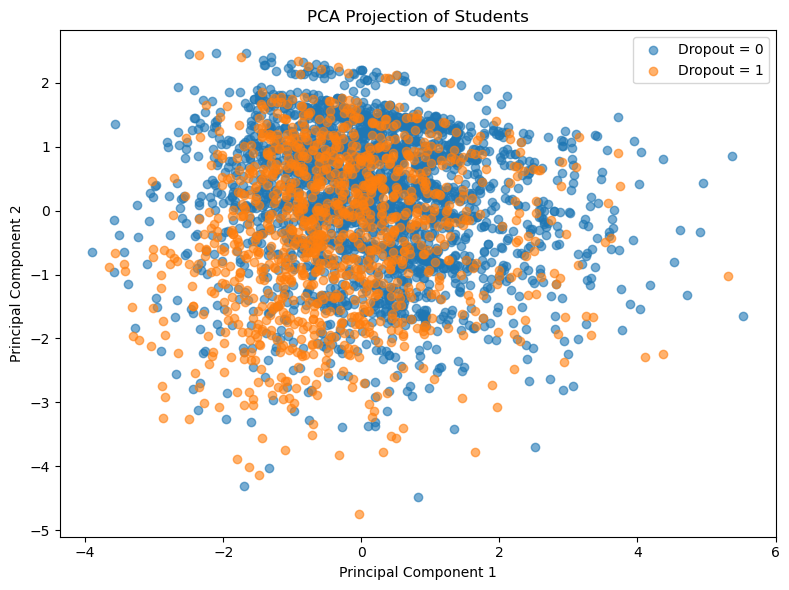

In [32]:
pca_2d = PCA(n_components=2)

X_train_pca_2d = pca_2d.fit_transform(
    X_train_numeric_scaled
)

pca_df = pd.DataFrame(
    X_train_pca_2d,
    columns=["PC1", "PC2"]
)

pca_df["Dropout"] = y_train.values

plt.figure(figsize=(8, 6))

for class_value in sorted(pca_df["Dropout"].unique()):

    subset = pca_df[
        pca_df["Dropout"] == class_value
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Dropout = {class_value}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Students")
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
pca_loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=numerical_features,
    columns=["PC1", "PC2"]
)

print("PCA Loadings:")
display(pca_loadings)

PCA Loadings:


,PC1,PC2
Previous qualification (grade),0.640890,-0.098428
Admission grade,0.621511,-0.101552
Age at enrollment,-0.216179,-0.467681
Unemployment rate,0.192765,-0.383603
Inflation rate,-0.033383,-0.225909
GDP,-0.142766,0.516219
Parental_Qualification_Same,-0.203662,-0.436130
Parental_Occupation_Same,-0.182035,-0.279456
Financial_Risk_Flag,-0.151598,-0.168227


In [34]:
print("STEP 3 PREPROCESSING SUMMARY")
print("=" * 55)

print(f"Original observations: {len(df):,}")
print(f"Original predictors: {df.shape[1] - 2}")

print(f"\nTraining observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

print(f"\nEarly-stage categorical features: {len(categorical_features)}")
print(f"Early-stage numerical features: {len(numerical_features)}")

print(
    f"\nPost-enrollment variables excluded from primary model: "
    f"{len(post_enrollment_features)}"
)

print(
    f"\nProcessed feature count after encoding: "
    f"{X_train_processed.shape[1]}"
)

print(
    f"Selected feature count: "
    f"{X_train_selected.shape[1]}"
)

print(
    f"PCA components for 90% variance: "
    f"{n_components_90}"
)

STEP 3 PREPROCESSING SUMMARY
Original observations: 4,424
Original predictors: 36

Training observations: 3,539
Testing observations: 885

Early-stage categorical features: 19
Early-stage numerical features: 9

Post-enrollment variables excluded from primary model: 12

Processed feature count after encoding: 245
Selected feature count: 49
PCA components for 90% variance: 8


## Step 3 — Preprocessing & Feature Engineering Conclusions

The raw dataset was transformed into a modelling-ready representation while preserving the original data. The three-class outcome was converted into a binary dropout target, where Dropout represents the positive class and Enrolled/Graduate represent the non-dropout class.

A stratified train-test split was performed before fitting preprocessing transformations to prevent information leakage. Numerical variables were median-imputed and standardized, while categorical variables were imputed using the most frequent category and one-hot encoded.

Post-enrollment curricular-unit variables were excluded from the primary early-risk modelling dataset because they contain academic information generated after enrolment and could introduce temporal leakage. This decision aligns with the project's objective of supporting earlier intervention.

Applied EDA examined numerical distributions, potential outliers, relationships between numerical variables and dropout, categorical group differences, and correlations among continuous variables.

Mutual information was used as a filter-based feature-selection method to identify features with the strongest association with the binary target. PCA was also applied to the standardized continuous variables to investigate dimensionality reduction and the amount of variance captured by a smaller number of components.

No observations were automatically removed solely because they were identified as statistical outliers. Outlier treatment will instead be based on domain meaning and model behaviour.

In [35]:
# Export Step 3 artefacts for Step 4

import os
import json
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(X_train_selected, "artifacts/X_train_selected.joblib")
joblib.dump(X_test_selected, "artifacts/X_test_selected.joblib")
joblib.dump(y_train, "artifacts/y_train.joblib")
joblib.dump(y_test, "artifacts/y_test.joblib")
joblib.dump(selected_features, "artifacts/selected_features.joblib")
joblib.dump(preprocessor, "artifacts/preprocessor.joblib")

step3_config = {
    "random_state": 42,
    "train_rows": X_train_selected.shape[0],
    "test_rows": X_test_selected.shape[0],
    "processed_features": 245,
    "selected_features": len(selected_features),
    "pca_components_90_percent": 8
}

with open("artifacts/step3_config.json", "w") as f:
    json.dump(step3_config, f, indent=2)

print("Step 3 artefacts exported successfully.")
print("Files saved in:", os.path.abspath("artifacts"))

Step 3 artefacts exported successfully.
Files saved in: C:\Users\Rufus1503\artifacts


In [36]:
# Export Step 3 artefacts for Step 4

import os
import json
import joblib

os.makedirs("artifacts", exist_ok=True)

joblib.dump(X_train_selected, "artifacts/X_train_selected.joblib")
joblib.dump(X_test_selected, "artifacts/X_test_selected.joblib")
joblib.dump(y_train, "artifacts/y_train.joblib")
joblib.dump(y_test, "artifacts/y_test.joblib")
joblib.dump(selected_features, "artifacts/selected_features.joblib")
joblib.dump(preprocessor, "artifacts/preprocessor.joblib")

step3_config = {
    "random_state": 42,
    "train_rows": X_train_selected.shape[0],
    "test_rows": X_test_selected.shape[0],
    "processed_features": X_train_processed.shape[1],
    "selected_features": X_train_selected.shape[1],
    "pca_components_90_percent": n_components_90
}

with open("artifacts/step3_config.json", "w") as f:
    json.dump(step3_config, f, indent=2)

print("Step 3 artefacts exported successfully.")
print("Training data:", X_train_selected.shape)
print("Testing data:", X_test_selected.shape)
print("Selected features:", len(selected_features))
print("Files saved in:", os.path.abspath("artifacts"))

TypeError: Object of type int64 is not JSON serializable

In [37]:
# Save Step 3 configuration

step3_config = {
    "random_state": int(42),
    "train_rows": int(X_train_selected.shape[0]),
    "test_rows": int(X_test_selected.shape[0]),
    "processed_features": int(X_train_processed.shape[1]),
    "selected_features": int(X_train_selected.shape[1]),
    "pca_components_90_percent": int(n_components_90)
}

with open("artifacts/step3_config.json", "w") as f:
    json.dump(step3_config, f, indent=2)

print("Step 3 artefacts exported successfully.")
print("Training data:", X_train_selected.shape)
print("Testing data:", X_test_selected.shape)
print("Selected features:", len(selected_features))
print("Configuration saved successfully.")

Step 3 artefacts exported successfully.
Training data: (3539, 49)
Testing data: (885, 49)
Selected features: 49
Configuration saved successfully.
